<div style="font-family:verdana;"><span style="font-size:400%;"> <center>Module 2: Permutation Tests</center> </span>


</div>



# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">Contents</p>

**<a href=#1.-Introduction>1. Introduction</a>**

**<a href=#2.-The-logic-of-permutation-testing>2. The logic of permutation testing</a>**

**<a href=#3.-A-first-two-sample-example>3. A first two-sample example</a>**

**<a href=#4.-Classical-comparison:-Welch&#39;s-two-sample-t-test>4. Classical comparison: Welch's two-sample t-test</a>**

**<a href=#5.-Permutation-test-using-difference-in-means>5. Permutation test using difference in means</a>**

**<a href=#6.-Changing-the-statistic:-difference-in-medians>6. Changing the statistic: difference in medians</a>**

**<a href=#7.-What-permutation-tests-assume>7. What permutation tests assume</a>**

**<a href=#8.-Strengths-and-limitations-of-permutation-tests>8. Strengths and limitations of permutation tests</a>**

**<a href=#9.-Optional-robustness-check:-introducing-an-outlier>9. Optional robustness check: introducing an outlier</a>**

**<a href=#10.-Takeaways>10. Takeaways</a>**

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">1. Introduction</p>

This notebook introduces permutation tests as a flexible nonparametric framework for hypothesis testing.

The main goals are:

1. understand the logic of permutation-based inference,
2. see how a permutation null distribution is constructed,
3. compare permutation tests with classical parametric testing,
4. understand how the choice of statistic changes the question being asked.

Permutation testing is especially important pedagogically because it makes hypothesis testing concrete. Instead of appealing only to a theoretical reference distribution, it constructs a null distribution directly from the observed data under the logic of relabeling.

## 📙 Import libraries and modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from nonparametric_stats.permutation import (
    difference_in_means,
    difference_in_medians,
    permutation_test,
)

## ⚙️ Configuration

In [2]:
rng = np.random.default_rng(42)

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">2. The logic of permutation testing</p>

A permutation test asks the following question:

If the null hypothesis were true, how unusual would the observed test statistic be?

The key idea is that under the null hypothesis of no real group effect, the labels identifying which observation belongs to which group should be exchangeable. If that is true, then one can repeatedly shuffle the labels, recompute the statistic, and use the resulting values to approximate the null distribution.

This produces a test that is often less dependent on parametric assumptions than a classical t-test.

### Exchangeability

The word **exchangeability** is crucial. A permutation test is not valid merely because we can shuffle labels mechanically. It is valid when the null hypothesis implies that the labels can be permuted without changing the joint structure of the data.

### Why this matters

This makes permutation testing a powerful teaching tool. It reveals that hypothesis testing is not fundamentally about memorizing distributions. It is about understanding what the null hypothesis says should be interchangeable.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">3. A first two-sample example</p>

We begin with a simple location-shift example. Two samples are simulated from normal distributions with the same variance but different means.

This is a convenient starting point because it lets us compare a classical parametric procedure, the Welch two-sample t-test, with permutation-based procedures in a relatively well-behaved setting.

In [3]:
x = rng.normal(loc=0.0, scale=1.0, size=25)
y = rng.normal(loc=0.5, scale=1.0, size=25)

group_summary = pd.DataFrame({
    "group": ["x", "y"],
    "n": [len(x), len(y)],
    "mean": [np.mean(x), np.mean(y)],
    "median": [np.median(x), np.median(y)],
    "std": [np.std(x, ddof=1), np.std(y, ddof=1)]
})

group_summary.round(4)

,group,n,mean,median,std
0,x,25,-0.0354,-0.0168,0.8311
1,y,25,0.7178,0.7322,0.6935


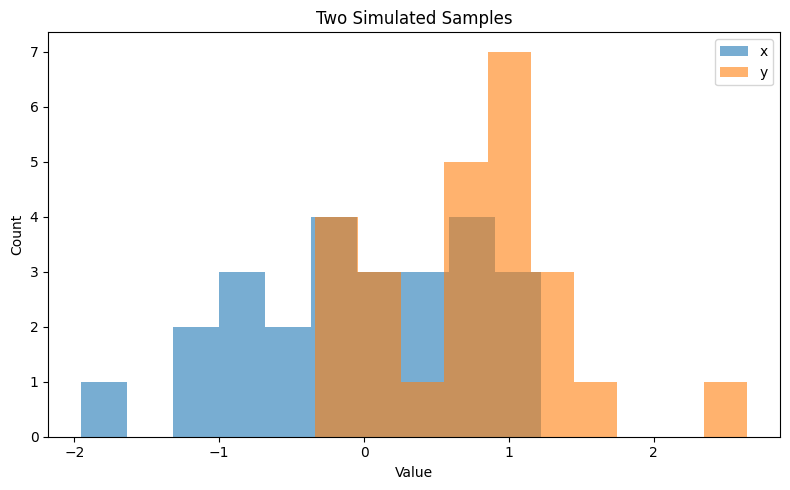

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(x, bins=10, alpha=0.6, label="x")
plt.hist(y, bins=10, alpha=0.6, label="y")
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Two Simulated Samples")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/permutation_two_group_hist.png", dpi=150, bbox_inches="tight")
plt.show()

The two groups appear similar in spread but shifted in location. This is a natural situation in which to compare mean-based and median-based testing procedures.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">4. Classical comparison: Welch's two-sample t-test</p>

Before constructing the permutation test, it is useful to compute a standard parametric benchmark.

Welch's t-test compares sample means while allowing unequal variances. Even though the present example is simulated with equal variances, Welch's version is often preferable in practice because it is more robust to variance differences than the pooled t-test.

In [5]:
ttest = stats.ttest_ind(x, y, equal_var=False)
ttest

TtestResult(statistic=np.float64(-3.4791476206436283), pvalue=np.float64(0.0011033189774530248), df=np.float64(46.509888447698344))

In [6]:
ttest_summary = pd.DataFrame({
    "quantity": ["t statistic", "p-value"],
    "value": [ttest.statistic, ttest.pvalue],
})

ttest_summary.round(4)

,quantity,value
0,t statistic,-3.4791
1,p-value,0.0011


This gives a familiar parametric point of comparison. The test is built around the difference in sample means and a theoretical reference distribution for the t-statistic.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">5. Permutation test using difference in means</p>

A permutation test is not tied to a single statistic. One must choose a statistic that reflects the feature of the data one cares about.

We begin with the difference in means, which makes the permutation test most comparable to the t-test.

In [7]:
perm_mean = permutation_test(
    x,
    y,
    statistic_func=difference_in_means,
    n_resamples=5000,
    alternative="two-sided",
    random_state=42,
)

perm_mean["observed_stat"], perm_mean["p_value"]

(-0.753202036170138, 0.0016)

In [8]:
perm_mean_summary = pd.DataFrame({
    "quantity": ["Observed difference in means", "Permutation p-value"],
    "value": [perm_mean["observed_stat"], perm_mean["p_value"]],
})

perm_mean_summary.round(4)

,quantity,value
0,Observed difference in means,-0.7532
1,Permutation p-value,0.0016


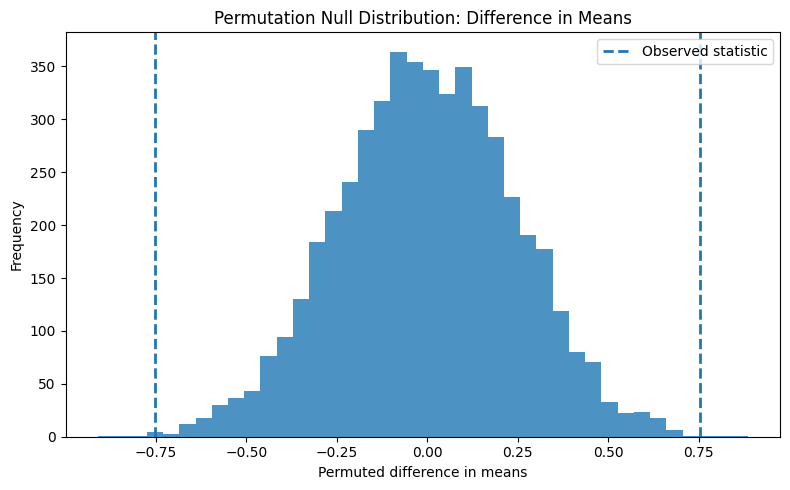

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(perm_mean["permuted_stats"], bins=40, alpha=0.8)
plt.axvline(perm_mean["observed_stat"], linestyle="--", linewidth=2, label="Observed statistic")
plt.axvline(-perm_mean["observed_stat"], linestyle="--", linewidth=2)
plt.xlabel("Permuted difference in means")
plt.ylabel("Frequency")
plt.title("Permutation Null Distribution: Difference in Means")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/permutation_null_mean_diff.png", dpi=150, bbox_inches="tight")
plt.show()

The histogram above is the estimated null distribution of the difference in means under repeated relabeling.

The dashed lines mark the observed statistic and its negative, corresponding to a two-sided test. The p-value is the proportion of permuted statistics at least as extreme as the observed value.

In [10]:
summary_mean = pd.DataFrame({
    "method": ["Welch t-test", "Permutation test (mean difference)"],
    "statistic": [ttest.statistic, perm_mean["observed_stat"]],
    "p_value": [ttest.pvalue, perm_mean["p_value"]],
})

summary_mean.round(4)

,method,statistic,p_value
0,Welch t-test,-3.4791,0.0011
1,Permutation test (mean difference),-0.7532,0.0016


### Interpretation

The Welch t-test and the mean-based permutation test are closely related in spirit here because both focus on differences in means.

The difference is in how the null distribution is obtained:

- the t-test uses a theoretical parametric reference distribution,
- the permutation test uses an empirical null distribution generated by relabeling.

In well-behaved settings, these procedures often agree fairly closely. The pedagogical advantage of the permutation test is that its logic is transparent: it shows exactly how the null distribution is built.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">6. Changing the statistic: difference in medians</p>

One of the most important lessons of permutation testing is that it is a framework, not a single fixed test.

To see this, we now change the statistic from the difference in means to the difference in medians.

In [11]:
perm_median = permutation_test(
    x,
    y,
    statistic_func=difference_in_medians,
    n_resamples=5000,
    alternative="two-sided",
    random_state=42,
)

perm_median["observed_stat"], perm_median["p_value"]

(-0.7489624805710086, 0.0272)

In [12]:
perm_median_summary = pd.DataFrame({
    "quantity": ["Observed difference in medians", "Permutation p-value"],
    "value": [perm_median["observed_stat"], perm_median["p_value"]],
})

perm_median_summary.round(4)

,quantity,value
0,Observed difference in medians,-0.7490
1,Permutation p-value,0.0272


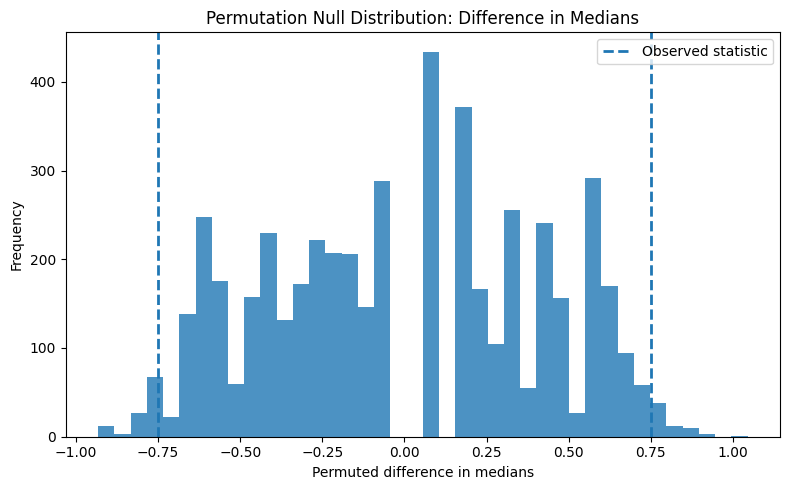

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(perm_median["permuted_stats"], bins=40, alpha=0.8)
plt.axvline(perm_median["observed_stat"], linestyle="--", linewidth=2, label="Observed statistic")
plt.axvline(-perm_median["observed_stat"], linestyle="--", linewidth=2)
plt.xlabel("Permuted difference in medians")
plt.ylabel("Frequency")
plt.title("Permutation Null Distribution: Difference in Medians")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/permutation_null_median_diff.png", dpi=150, bbox_inches="tight")
plt.show()

The shape of the permutation distribution changes because the statistic itself has changed. This highlights a central feature of permutation testing: the resampling mechanism provides the null distribution, but the statistic determines what feature of the data is being emphasized.

In [14]:
summary_all = pd.DataFrame({
    "method": [
        "Welch t-test",
        "Permutation test (mean difference)",
        "Permutation test (median difference)",
    ],
    "statistic": [
        ttest.statistic,
        perm_mean["observed_stat"],
        perm_median["observed_stat"],
    ],
    "p_value": [
        ttest.pvalue,
        perm_mean["p_value"],
        perm_median["p_value"],
    ],
})

summary_all.round(4)

,method,statistic,p_value
0,Welch t-test,-3.4791,0.0011
1,Permutation test (mean difference),-0.7532,0.0016
2,Permutation test (median difference),-0.7490,0.0272


### What changes when the statistic changes?

The mean-based permutation test is most sensitive to mean shifts. The median-based permutation test instead targets changes in central tendency measured through medians.

This does not mean one is universally better. It means the analyst must decide which feature of the data is substantively important and which kinds of contamination or irregularity are plausible.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">7. What permutation tests assume</p>

Permutation tests are often described as “assumption light,” but they are not assumption free.

### Main assumption
The central requirement is that under the null hypothesis, the labels are exchangeable.

### What this means
If the null does not justify relabeling, the permutation distribution is not the correct null distribution.

### Important nuance
A permutation test can avoid strong distributional assumptions such as normality, but it still depends on the structural validity of the relabeling argument.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">8. Strengths and limitations of permutation tests</p>

**Strengths**
- conceptually transparent,
- flexible choice of statistic,
- often less dependent on parametric distributional assumptions,
- useful in small or irregular samples,
- excellent for teaching the logic of inference.

**Limitations**
- validity depends on exchangeability,
- can be computationally expensive for large resample counts,
- interpretation depends heavily on the chosen statistic,
- not automatically superior to parametric tests.

Permutation tests are best understood as a powerful framework for hypothesis testing, not as a universal replacement for classical methods.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">9. Optional robustness check: introducing an outlier</p>

To make the role of the statistic more concrete, we now contaminate one sample with an outlier and compare how the procedures respond.

This helps show why mean-based and median-based procedures can behave differently even within the same permutation framework.

In [15]:
x_out = x.copy()
y_out = y.copy()
y_out[0] = 8.0

ttest_out = stats.ttest_ind(x_out, y_out, equal_var=False)

perm_mean_out = permutation_test(
    x_out,
    y_out,
    statistic_func=difference_in_means,
    n_resamples=5000,
    alternative="two-sided",
    random_state=42,
)

perm_median_out = permutation_test(
    x_out,
    y_out,
    statistic_func=difference_in_medians,
    n_resamples=5000,
    alternative="two-sided",
    random_state=42,
)

summary_out = pd.DataFrame({
    "method": [
        "Welch t-test with outlier",
        "Permutation test (mean difference) with outlier",
        "Permutation test (median difference) with outlier",
    ],
    "statistic": [
        ttest_out.statistic,
        perm_mean_out["observed_stat"],
        perm_median_out["observed_stat"],
    ],
    "p_value": [
        ttest_out.pvalue,
        perm_mean_out["p_value"],
        perm_median_out["p_value"],
    ],
})

summary_out.round(4)

,method,statistic,p_value
0,Welch t-test with outlier,-2.9533,0.0055
1,Permutation test (mean difference) with outlier,-1.0673,0.0006
2,Permutation test (median difference) with outlier,-0.8822,0.0078


The outlier influences the mean more strongly than the median. As a result, the mean-based procedures typically react more sharply to this contamination than the median-based permutation test.

This example reinforces the larger lesson: even within the same resampling framework, the statistic determines what kind of signal and what kind of distortion the test is most sensitive to.

In [16]:
final_summary = pd.DataFrame({
    "concept": [
        "Exchangeability",
        "Permutation null distribution",
        "Choice of statistic",
        "Robustness",
    ],
    "meaning": [
        "Under the null, labels can be shuffled without changing the joint structure",
        "Built empirically by repeated relabeling",
        "Determines what feature of the data is being tested",
        "Depends partly on which statistic is chosen",
    ],
})

final_summary

,concept,meaning
0,Exchangeability,"Under the null, labels can be shuffled without..."
1,Permutation null distribution,Built empirically by repeated relabeling
2,Choice of statistic,Determines what feature of the data is being t...
3,Robustness,Depends partly on which statistic is chosen


# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">10. Takeaways</p>

This notebook introduced permutation testing as a flexible nonparametric framework for inference.

- A permutation test constructs its null distribution empirically by relabeling the data.
- Its validity depends on exchangeability under the null.
- The choice of statistic is central: it determines what aspect of the data the test is sensitive to.
- Permutation testing is valuable both practically and pedagogically because it makes the logic of hypothesis testing visible.

The deeper lesson is that inference is not only about formulas. It is also about what the null hypothesis implies should be interchangeable.